In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data=pd.read_csv("solar_weather.csv")

In [ ]:
num_rows, num_columns = data.shape
print(f'Dataset Size: {num_rows} rows and {num_columns} columns')

Dataset Size: 196776 rows and 17 columns


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    196776 non-null  object 
 1   Energy delta[Wh]        196776 non-null  int64  
 2   GHI                     196776 non-null  float64
 3   temp                    196776 non-null  float64
 4   pressure                196776 non-null  int64  
 5   humidity                196776 non-null  int64  
 6   wind_speed              196776 non-null  float64
 7   rain_1h                 196776 non-null  float64
 8   snow_1h                 196776 non-null  float64
 9   clouds_all              196776 non-null  int64  
 10  isSun                   196776 non-null  int64  
 11  sunlightTime            196776 non-null  int64  
 12  dayLength               196776 non-null  int64  
 13  SunlightTime/daylength  196776 non-null  float64
 14  weather_type        

In [ ]:

# Rename the column if necessary (e.g., if it contains spaces)
data.rename(columns={' Time ': 'Time'}, inplace=True)  # Adjust the column name based on the actual output

# Convert 'Time' column to datetime format
data['Time'] = pd.to_datetime(data['Time'], format='%Y-%m-%d %H:%M:%S')

# Set 'Time' as the index for time-series analysis
data.set_index('Time', inplace=True)

# Display the first few rows
data.head()


,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
Time,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2017-01-01 00:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2017-01-01 00:30:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2017-01-01 00:45:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2017-01-01 01:00:00,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1,1


# Data Acquisition and Initial Setup:
o	Access and download the "Global Renewable Energy Production" dataset from a renewable energy database or research institution.

o	Load the dataset into a Python environment using pandas, ensuring the data is well-structured for time-series analysis.

o	Conduct a preliminary assessment to understand data features such as energy output levels, weather conditions, and temporal patterns.


Energy delta[Wh]          0
GHI                       0
temp                      0
pressure                  0
humidity                  0
wind_speed                0
rain_1h                   0
snow_1h                   0
clouds_all                0
isSun                     0
sunlightTime              0
dayLength                 0
SunlightTime/daylength    0
weather_type              0
hour                      0
month                     0
dtype: int64


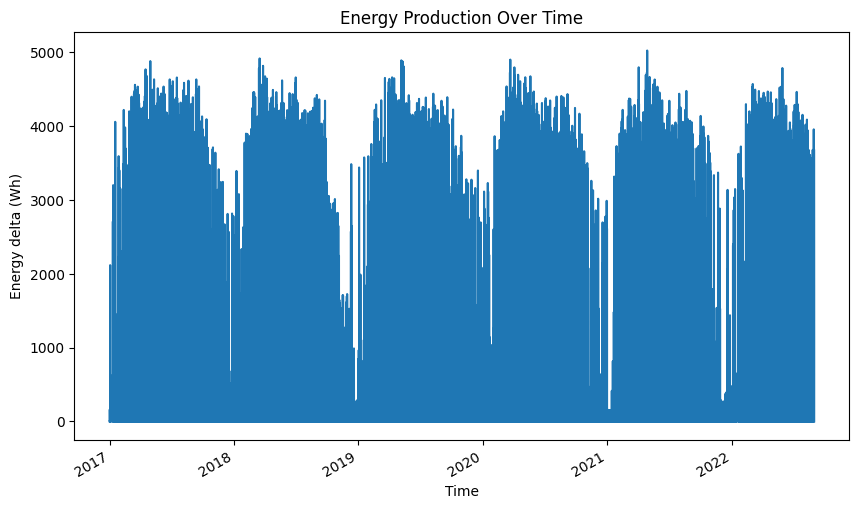

In [ ]:

# Checking for missing values
print(data.isnull().sum())

# Plotting energy production trends
import matplotlib.pyplot as plt

data['Energy delta[Wh]'].plot(figsize=(10,6))
plt.title('Energy Production Over Time')
plt.xlabel('Time')
plt.ylabel('Energy delta (Wh)')
plt.show()


<ipython-input-14-9eb47dcd6423>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_energy = data['Energy delta[Wh]'].resample('M').mean()


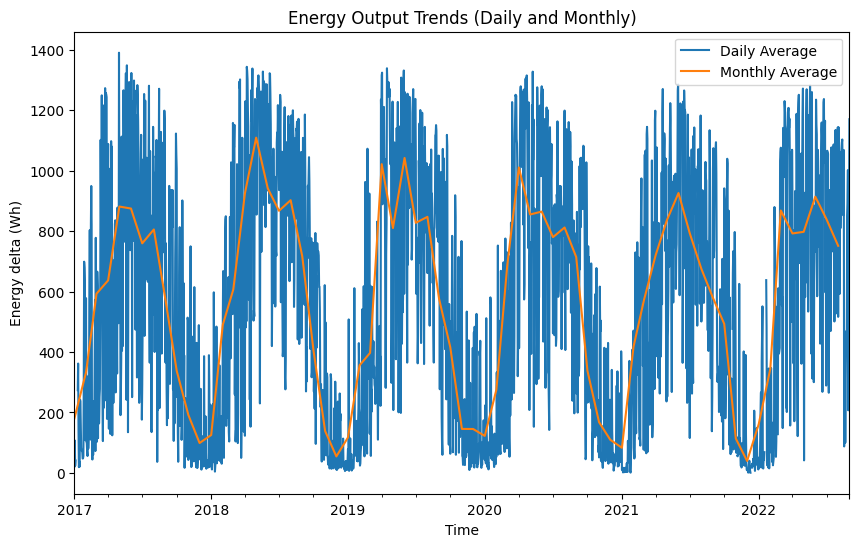

In [ ]:
# Resample energy data to daily and monthly averages
daily_energy = data['Energy delta[Wh]'].resample('D').mean()
monthly_energy = data['Energy delta[Wh]'].resample('M').mean()

# Plot daily and monthly trends
daily_energy.plot(figsize=(10, 6), label='Daily Average')
monthly_energy.plot(figsize=(10, 6), label='Monthly Average')
plt.title('Energy Output Trends (Daily and Monthly)')
plt.xlabel('Time')
plt.ylabel('Energy delta (Wh)')
plt.legend()
plt.show()




In [ ]:
# Correlation between weather conditions and energy output
weather_columns = ['temp', 'pressure', 'humidity', 'wind_speed', 'rain_1h', 'snow_1h', 'clouds_all']
correlation_matrix = data[['Energy delta[Wh]'] + weather_columns].corr()

print(correlation_matrix)



                  Energy delta[Wh]      temp  pressure  humidity  wind_speed  \
Energy delta[Wh]          1.000000  0.378554  0.115219 -0.544407    0.029385   
temp                      0.378554  1.000000 -0.066909 -0.517358   -0.080258   
pressure                  0.115219 -0.066909  1.000000 -0.120481   -0.313964   
humidity                 -0.544407 -0.517358 -0.120481  1.000000   -0.112949   
wind_speed                0.029385 -0.080258 -0.313964 -0.112949    1.000000   
rain_1h                  -0.059881  0.073826 -0.201842  0.126620    0.123506   
snow_1h                  -0.050914 -0.123244 -0.135485  0.095623    0.072749   
clouds_all               -0.190241 -0.117245 -0.263852  0.285336    0.146116   

                   rain_1h   snow_1h  clouds_all  
Energy delta[Wh] -0.059881 -0.050914   -0.190241  
temp              0.073826 -0.123244   -0.117245  
pressure         -0.201842 -0.135485   -0.263852  
humidity          0.126620  0.095623    0.285336  
wind_speed        0.1235

FEATURE ENG



In [ ]:
# Lag features for energy output (e.g., lag of 1 hour and 24 hours)
data['lag_1h'] = data['Energy delta[Wh]'].shift(1)
data['lag_24h'] = data['Energy delta[Wh]'].shift(24)

# Rolling window features for energy output and temperature (e.g., rolling mean over the past 24 hours)
data['rolling_mean_24h'] = data['Energy delta[Wh]'].rolling(window=24).mean()
data['rolling_temp_24h'] = data['temp'].rolling(window=24).mean()

# Interaction feature: temp * wind speed
data['temp_wind_interaction'] = data['temp'] * data['wind_speed']

# Extract temporal features: day of the week and season
data['day_of_week'] = data.index.dayofweek
data['month'] = data.index.month
data['season'] = data['month'].apply(lambda x: (x%12 + 3)//3)  # 1: Winter, 2: Spring, 3: Summer, 4: Fall
data.head()



,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,...,weather_type,hour,month,lag_1h,lag_24h,rolling_mean_24h,rolling_temp_24h,temp_wind_interaction,day_of_week,season
Time,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,...,4,0,1,NaN,NaN,NaN,NaN,7.84,6,1
2017-01-01 00:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,...,4,0,1,0.0,NaN,NaN,NaN,7.84,6,1
2017-01-01 00:30:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,...,4,0,1,0.0,NaN,NaN,NaN,7.84,6,1
2017-01-01 00:45:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,...,4,0,1,0.0,NaN,NaN,NaN,7.84,6,1
2017-01-01 01:00:00,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,...,4,1,1,0.0,NaN,NaN,NaN,8.84,6,1


DATA TRANFMN

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standardize continuous variables
continuous_cols = ['Energy delta[Wh]', 'temp', 'pressure', 'humidity', 'wind_speed', 'sunlightTime', 'rolling_mean_24h']
scaler = StandardScaler()
data[continuous_cols] = scaler.fit_transform(data[continuous_cols])

# Alternatively, normalize the data to [0, 1] range
normalizer = MinMaxScaler()
data[continuous_cols] = normalizer.fit_transform(data[continuous_cols])
data.head()


,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,...,weather_type,hour,month,lag_1h,lag_24h,rolling_mean_24h,rolling_temp_24h,temp_wind_interaction,day_of_week,season
Time,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,0.0,0.0,0.347328,0.628571,1.0,0.342657,0.0,0.0,100,0,...,4,0,1,NaN,NaN,NaN,NaN,7.84,6,1
2017-01-01 00:15:00,0.0,0.0,0.347328,0.628571,1.0,0.342657,0.0,0.0,100,0,...,4,0,1,0.0,NaN,NaN,NaN,7.84,6,1
2017-01-01 00:30:00,0.0,0.0,0.347328,0.628571,1.0,0.342657,0.0,0.0,100,0,...,4,0,1,0.0,NaN,NaN,NaN,7.84,6,1
2017-01-01 00:45:00,0.0,0.0,0.347328,0.628571,1.0,0.342657,0.0,0.0,100,0,...,4,0,1,0.0,NaN,NaN,NaN,7.84,6,1
2017-01-01 01:00:00,0.0,0.0,0.349237,0.614286,1.0,0.363636,0.0,0.0,100,0,...,4,1,1,0.0,NaN,NaN,NaN,8.84,6,1


MODEL SETTING

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Define feature columns and target column based on actual names
feature_columns = ['GHI', 'temp', 'pressure', 'humidity', 'wind_speed', 'rain_1h', 'clouds_all']
target_column = 'Energy delta[Wh]'

# Extract the features (X) and target (y)
X = data[feature_columns]
y = data[target_column]

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on validation set and evaluate
rf_val_predictions = rf_model.predict(X_val)
rf_val_mae = mean_absolute_error(y_val, rf_val_predictions)
rf_val_rmse = mean_squared_error(y_val, rf_val_predictions, squared=False)

print("Random Forest Validation MAE:", rf_val_mae)
print("Random Forest Validation RMSE:", rf_val_rmse)

Random Forest Validation MAE: 0.030104872084798347
Random Forest Validation RMSE: 0.0658586593309636


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val_lstm = X_val.values.reshape((X_val.shape[0], 1, X_val.shape[1]))

# Define the LSTM model
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(1, X_train.shape[1])),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the LSTM model
lstm_model.fit(X_train_lstm, y_train, epochs=100, batch_size=32, validation_data=(X_val_lstm, y_val),
               callbacks=[early_stopping], verbose=1)

# Predict and evaluate on validation set
lstm_val_predictions = lstm_model.predict(X_val_lstm).flatten()
lstm_val_mae = mean_absolute_error(y_val, lstm_val_predictions)
lstm_val_rmse = mean_squared_error(y_val, lstm_val_predictions, squared=False)

print("LSTM Validation MAE:", lstm_val_mae)
print("LSTM Validation RMSE:", lstm_val_rmse)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.6086 - val_loss: 0.0077
Epoch 2/100
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0081 - val_loss: 0.0071
Epoch 3/100
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0074 - val_loss: 0.0066
Epoch 4/100
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.0068 - val_loss: 0.0063
Epoch 5/100
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0066 - val_loss: 0.0063
Epoch 6/100
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0063 - val_loss: 0.0071
Epoch 7/100
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0061 - val_loss: 0.0069
Epoch 8/100
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.0061 - val_loss: 0.0065
Epoch 9/100
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 10/100
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0059 - val_loss: 0.0060
Epoch 11/100
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0060 - val_loss: 0.0061
Epoch 12

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
lstm_val_predictions


array([ 0.00925623, -0.00290957,  0.3155238 , ..., -0.00282066,
       -0.00245626,  0.5162455 ], dtype=float32)

In [ ]:
from xgboost import XGBRegressor

# Initialize and train an XGBoost model
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict and evaluate on validation set
xgb_val_predictions = xgb_model.predict(X_val)
xgb_val_mae = mean_absolute_error(y_val, xgb_val_predictions)
xgb_val_rmse = mean_squared_error(y_val, xgb_val_predictions, squared=False)

print("XGBoost Validation MAE:", xgb_val_mae)
print("XGBoost Validation RMSE:", xgb_val_rmse)


XGBoost Validation MAE: 0.03314255587246208
XGBoost Validation RMSE: 0.07098502482759517


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model only on target variable (univariate approach)
arima_model = ARIMA(y_train, order=(5, 1, 0))  # Adjust order based on ACF/PACF plots
arima_model = arima_model.fit()

# Forecast for validation period
arima_val_forecast = arima_model.forecast(steps=len(y_val))
arima_val_mae = mean_absolute_error(y_val, arima_val_forecast)
arima_val_rmse = mean_squared_error(y_val, arima_val_forecast, squared=False)

print("ARIMA Validation MAE:", arima_val_mae)
print("ARIMA Validation RMSE:", arima_val_rmse)


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm

ARIMA Validation MAE: 0.1781615250266317
ARIMA Validation RMSE: 0.21439856892097325


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train a Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict and evaluate on validation set
lin_reg_val_predictions = lin_reg.predict(X_val)
lin_reg_val_mae = mean_absolute_error(y_val, lin_reg_val_predictions)
lin_reg_val_rmse = mean_squared_error(y_val, lin_reg_val_predictions, squared=False)

print("Linear Regression Validation MAE:", lin_reg_val_mae)
print("Linear Regression Validation RMSE:", lin_reg_val_rmse)


Linear Regression Validation MAE: 0.04667000607554449
Linear Regression Validation RMSE: 0.08292693106351676


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train a Decision Tree Regressor
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)  # Adjust max_depth for tree complexity
tree_reg.fit(X_train, y_train)

# Predict and evaluate on validation set
tree_val_predictions = tree_reg.predict(X_val)
tree_val_mae = mean_absolute_error(y_val, tree_val_predictions)
tree_val_rmse = mean_squared_error(y_val, tree_val_predictions, squared=False)

print("Decision Tree Validation MAE:", tree_val_mae)
print("Decision Tree Validation RMSE:", tree_val_rmse)


Decision Tree Validation MAE: 0.03713635913276891
Decision Tree Validation RMSE: 0.07935507549198179


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


FINE TUNING

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error

# Define the model
def create_model(units=64, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(dropout_rate),
        LSTM(units),
        Dropout(dropout_rate),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Manually experiment with values
model = create_model(units=64, dropout_rate=0.3, learning_rate=0.001)

# Train with validation split
history = model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate on test set
y_pred = model.predict(X_test_lstm)
mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", mse)
